# Time Series  


---

## Agenda

- What is a time series (TS)?
  - Difference to other ML techniques
  - Components of a TS
- Prerequisites to make predictions
  - Stationarity
  - Hypothesis testing
- Analysing (decomposing) TS
- Predicting the future with autoregression
- ARIMA-models
  - Determination of the hyperparameters
  - automated solution
- Special considerations 
  - Imputation
  - Validation
- Outlook

## 1. Introduction

##### What is a time series (TS)?

- ordered sequence of observations at (equal) intervals of time
- no feature other than time
- observations not independent of each other
- objective: extrapolate into the future / imputation

## 2. Components of a TS

((0.0, 80.0), Text(0, 0.5, 'value'))

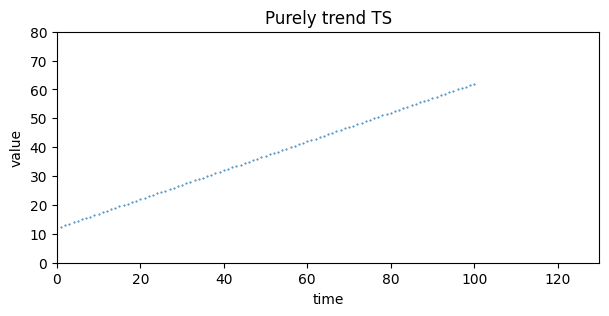

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime as dt

from sklearn.linear_model import LinearRegression


plt.rcParams['figure.figsize'] = (7, 3)
plt.scatter(t := np.arange(1,101), 12 + 0.5 * t, s=0.2)
plt.title('Purely trend TS')
plt.xlim(0, 130), plt.xlabel('time')
plt.ylim(0, 80), plt.ylabel('value')

((-5.0, 5.0), Text(0, 0.5, 'value'))

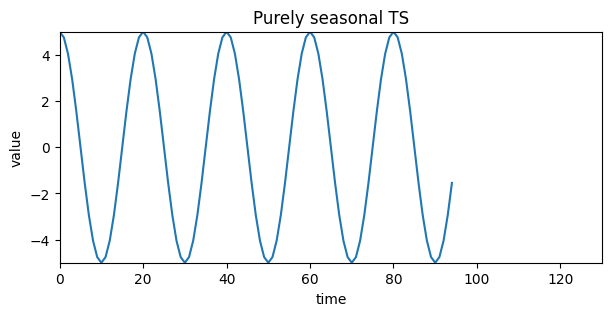

In [4]:
plt.plot(t := np.arange(0,30*np.pi),  5 * np.cos(0.1*np.pi*t))
plt.title('Purely seasonal TS')
plt.xlim(0, 130), plt.xlabel('time')
plt.ylim(-5, 5), plt.ylabel('value')

Can you extrapolate this TS?  
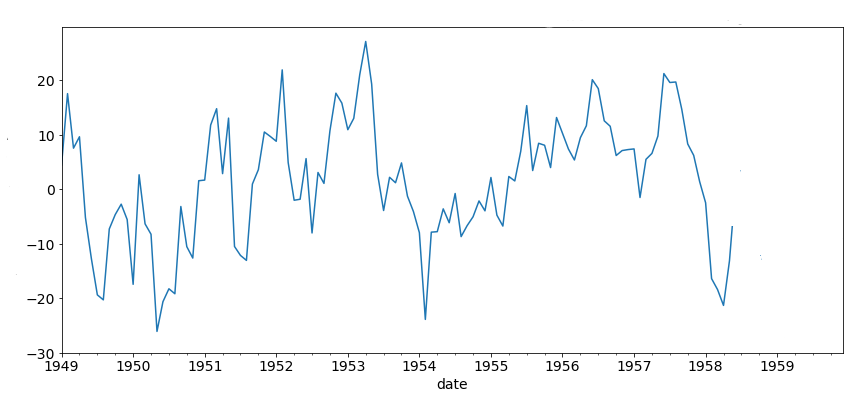

Usually TS consist of all 3 components  
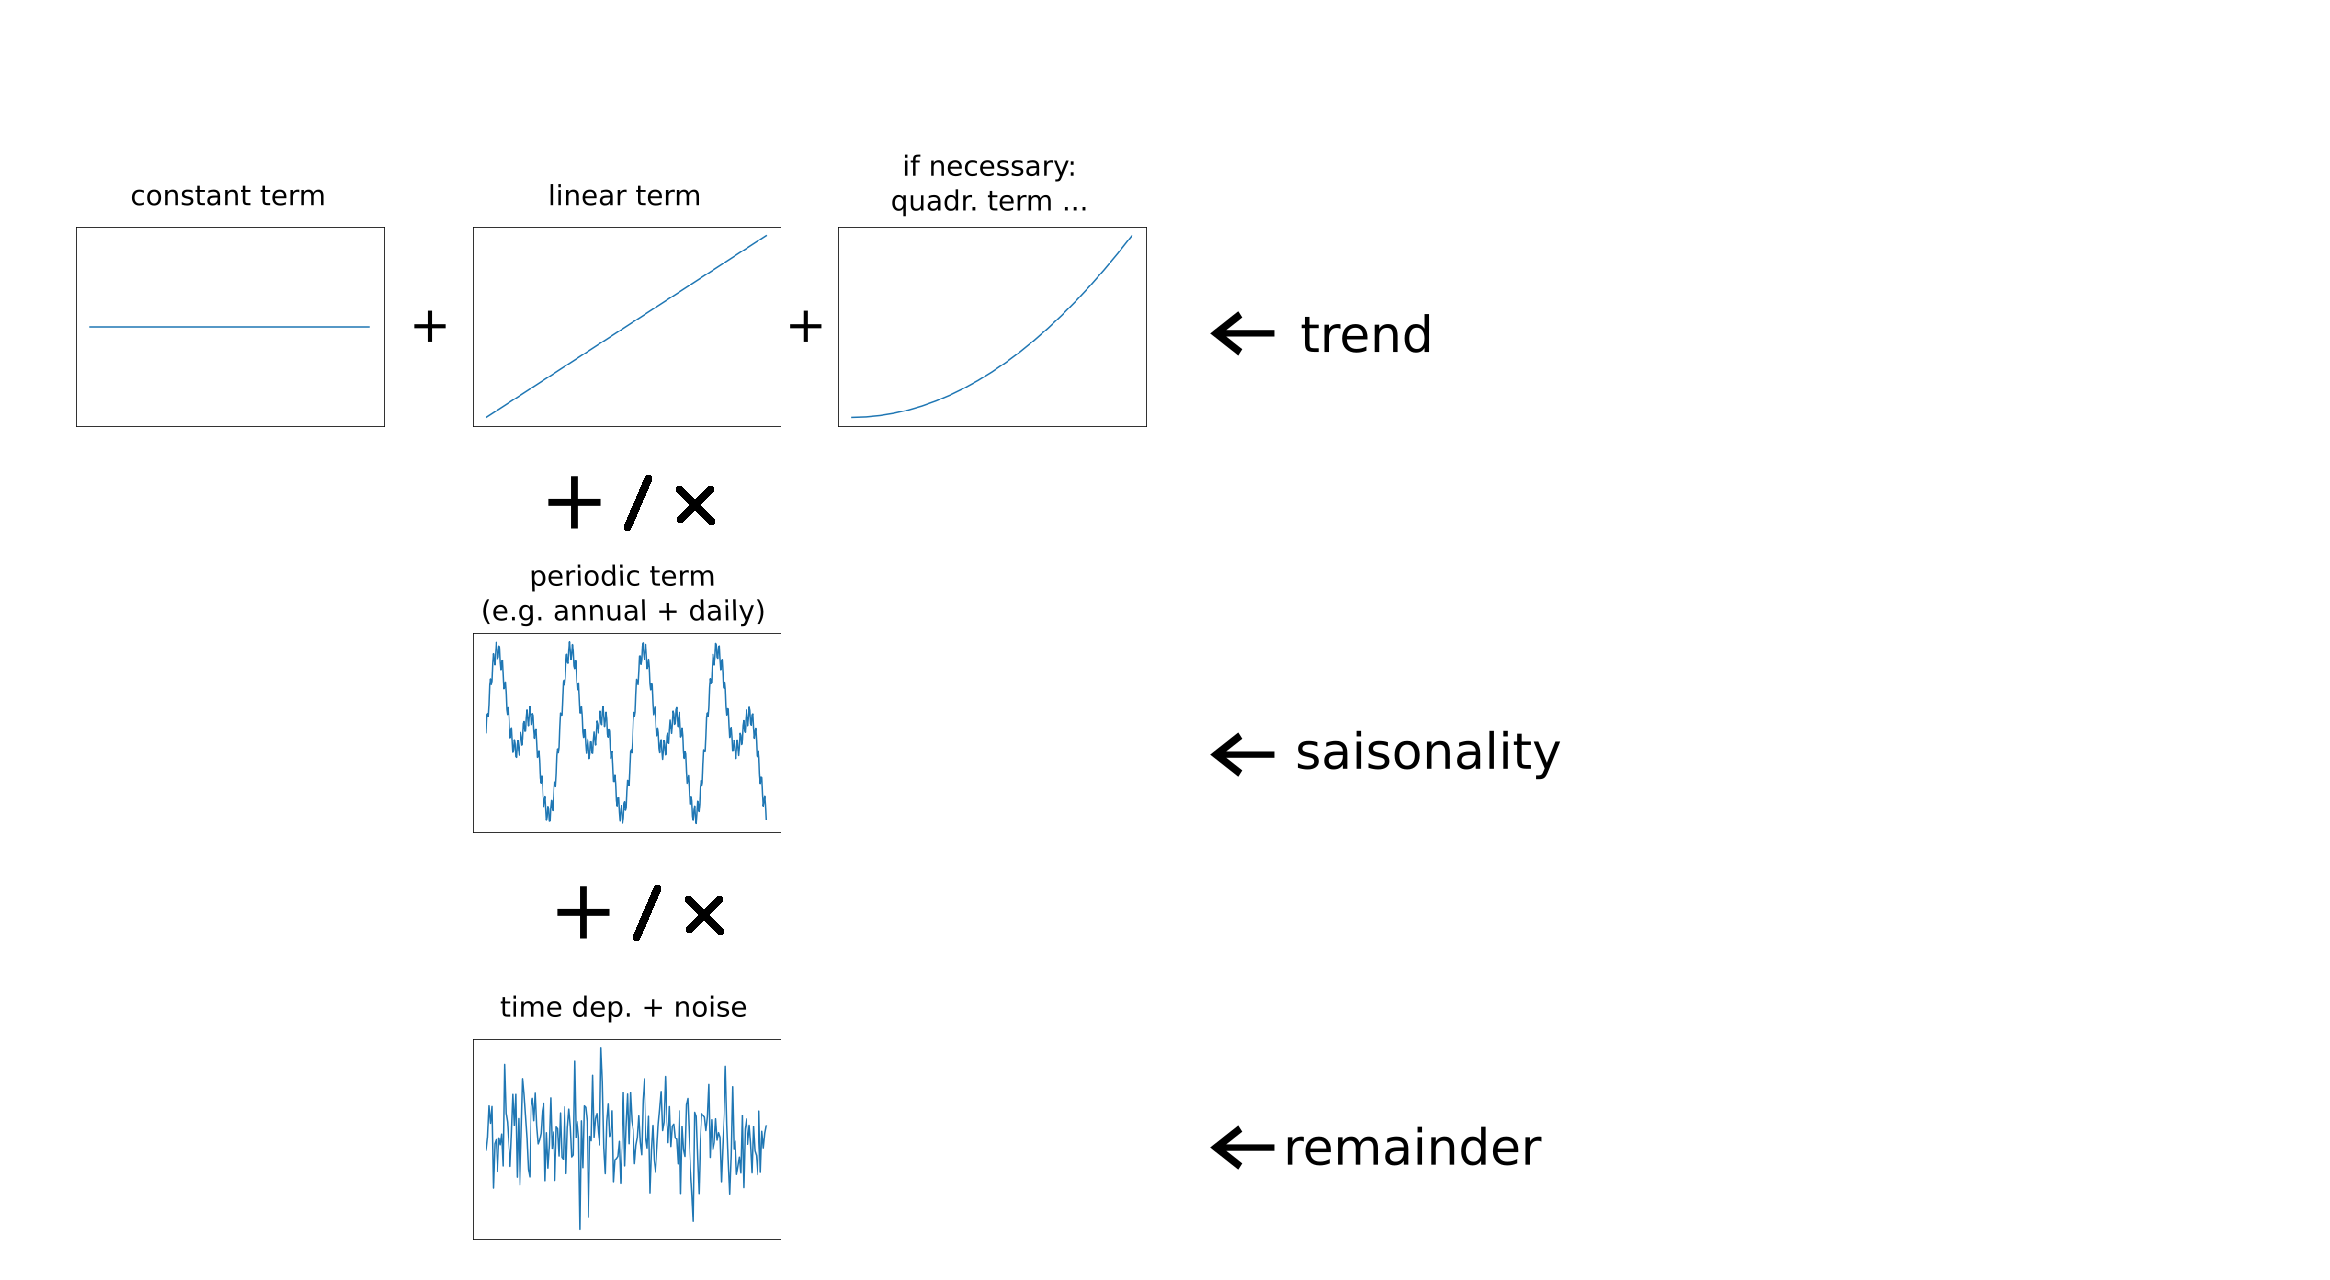  
Remainder is the most challenging portion of a TS.  
For making sophisticated forecasts, we first have to make a TS stationary.  

## 3. Stationarity

[Types of stationarities](https://en.wikipedia.org/wiki/Stationary_process)

* **Strict stationarity**: The time series is completely time invariant: The distributions of different time chunks is identical, no autocorrelation.  
(We will see later what "autocorrelation" means.)

* **Trend stationary**: Has a predictable trend. In this case, the overall mean trend equals the trend between consecutive steps.
  
* **Weak stationarity** (needed for autoregression, see below):

    1. constant mean  
    The mean does not change over time.  
    2. constant variance (mean deviation from the mean)  
     The variance does not change over time.  
    3. covariance independent of time  
     The covariance between any two lags only depends on the time distance between the lags. It must not depend on the absolute time position.   
     (again: "lag" will be explained later.)

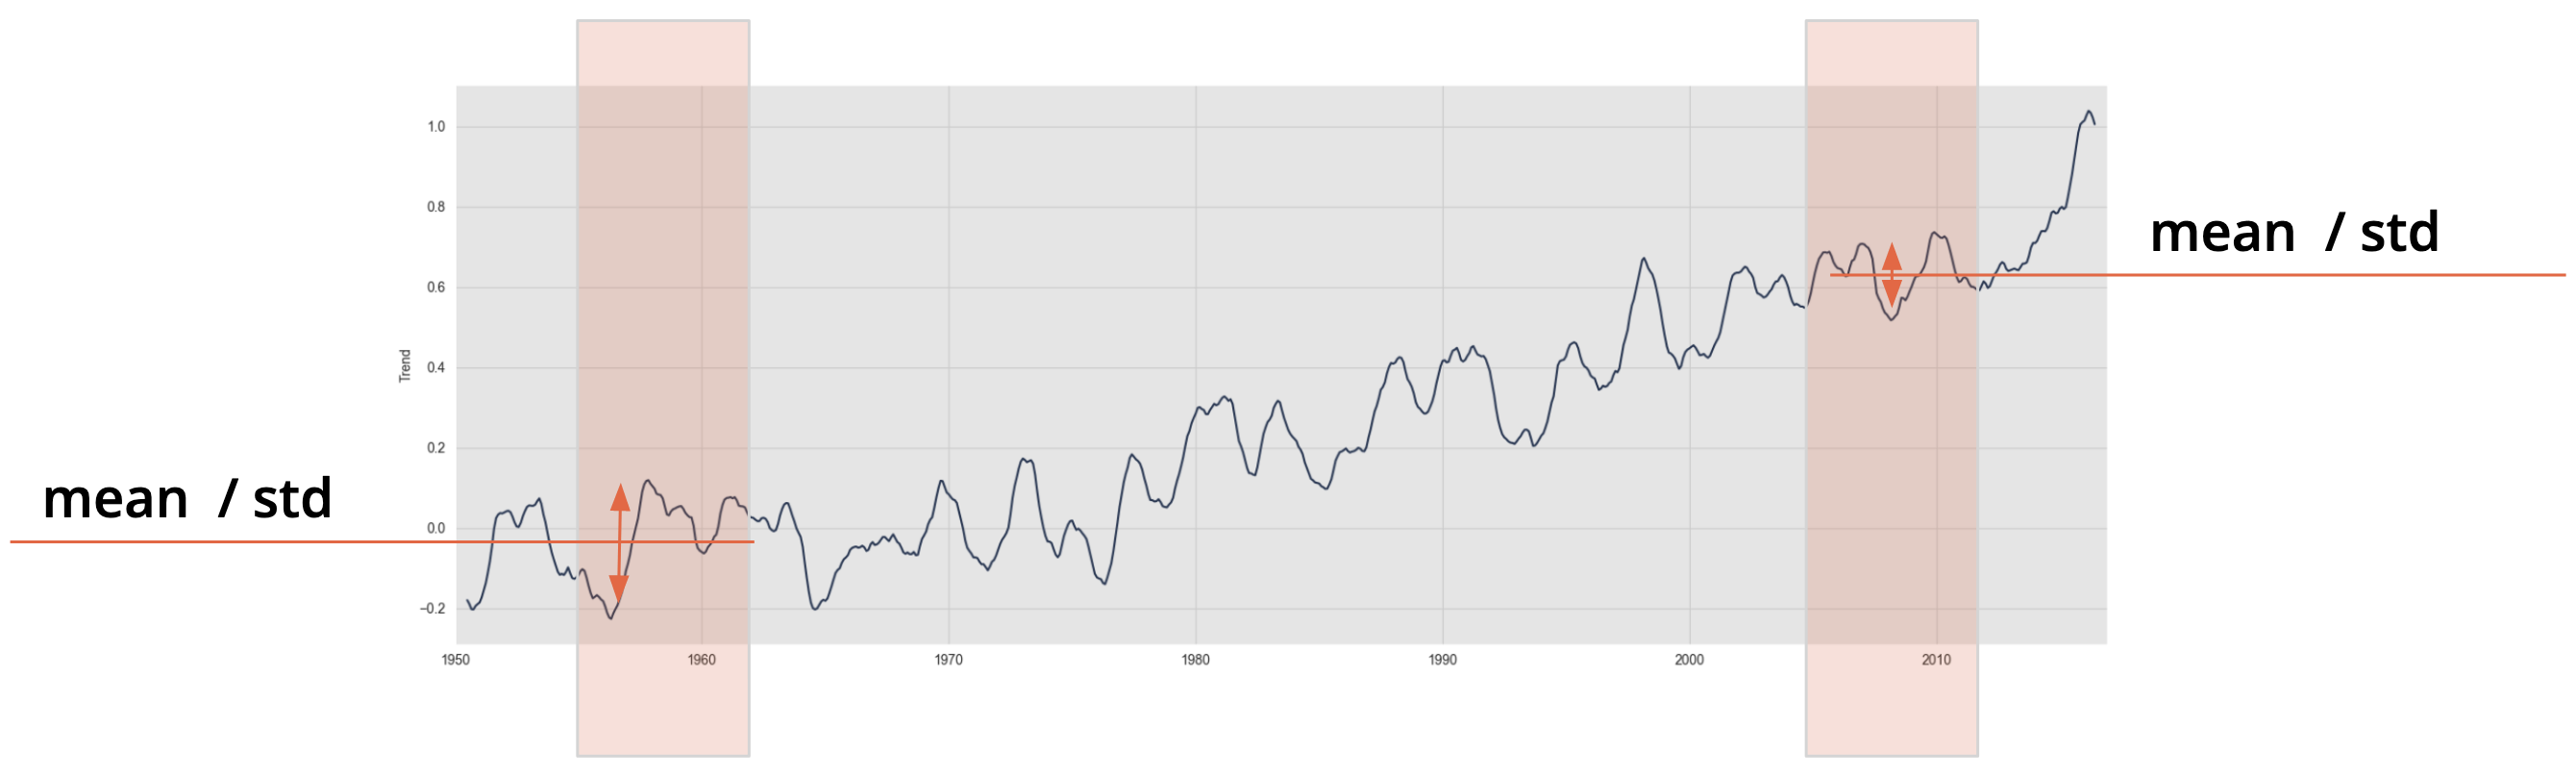

Side notes:  
- The conditions for stationarity require several observations. ('mean', 'variance', 'covariance' make little sense for only one observation.)  That means they refer to chunk sizes in time.  
- It is up to you to select an appropriate chunk size. It should be chosen according to the time scale. Thus 'stationarity' is somewhat **relative** w.r.t. chunk size.
- strict stationarity makes autoregression (see below) impossible, because there will be no correlation between the lags.

Which of these time series are weak stationary?

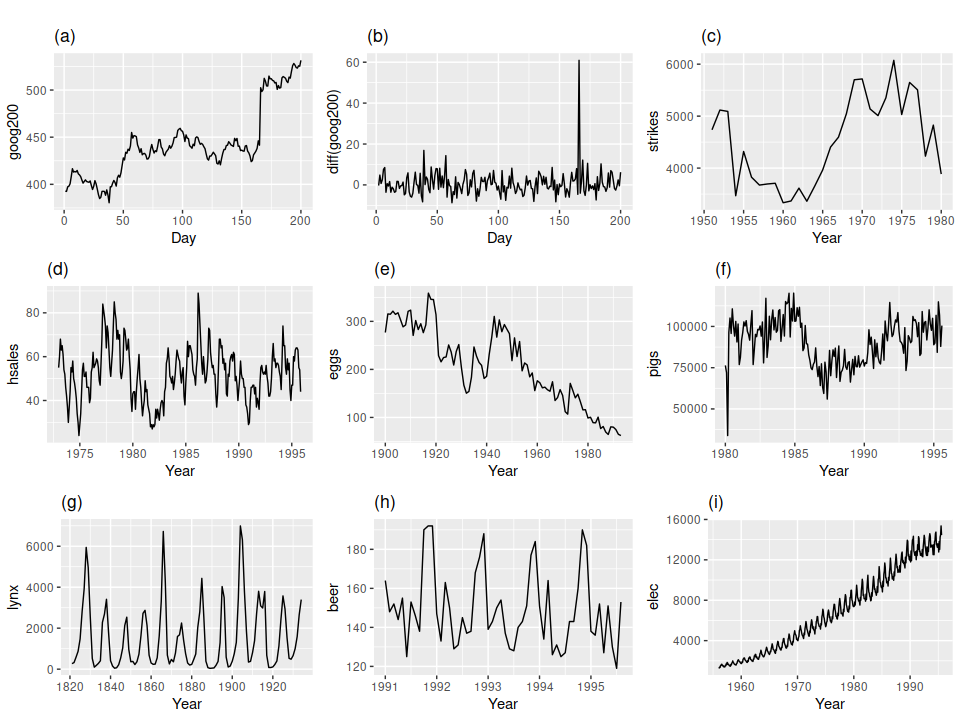

<span style="color:white">Answer: 2nd, although outlier; maybe bottom left</span>

### How to analytically test a time series for stationarity
with the Augmented Dickey-Fuller (ADF) test

As many test, also the ADF test ([link1, ](https://www.machinelearningplus.com/time-series/augmented-dickey-fuller-test/) [link2](https://www.statsmodels.org/0.6.1/generated/statsmodels.tsa.stattools.adfuller.html)) works by  
- first hypothesizing the opposite of what we want to show. This inital hypothesis is called **null hypothesis (H0)**: We hypothesize that a TS is **not** stationary.
- Lateron we hope to see from the test result that we can reject this H0. (Rejecting is often more easy than proving something.) The complement to H0 is called **alternative hypothesis (H1)**. If H1 it is the only alternative to H0, rejecting H0 means corroborating H1.

Find out more info about hypothesis testing [here.]( https://statisticsbyjim.com/hypothesis-testing/one-tailed-two-tailed-hypothesis-tests/)

In terms of the ADF test, the null hypothesis is that the time series is  *not* stationary. If the test result shows a small p value the TS *is* stationary.

In [7]:
from statsmodels.tsa.stattools import adfuller

white_noise = np.random.normal(size=1000)

adf_stats, p, used_lag, n_obs, levels, information_criterion = adfuller(white_noise)

print(f"""   
            adf: {round(adf_stats,2)}
            p: {p} 
            used lag: {used_lag} 
            number of observations: {n_obs}
            {round(levels['1%'],2)} (p < 0.01; CI = 99%) 
            {round(levels['5%'],2)} (p < 0.05; CI = 95%)
            {round(levels['10%'],2)} (p < 0.1 CI = 90%) 
            information criterion (AIC): {information_criterion}
            """)

   
            adf: -23.16
            p: 0.0 
            used lag: 1 
            number of observations: 998
            -3.44 (p < 0.01; CI = 99%) 
            -2.86 (p < 0.05; CI = 95%)
            -2.57 (p < 0.1 CI = 90%) 
            information criterion (AIC): 2901.373051397147
            


* The first number is the ADF test statistics. The more negative it is, the more confident we are that the series is stationary. This value is used to be compared with the values below.
* probability that null hypothesis will not be rejected
* number of lags used (look [here](https://www.machinelearningplus.com/time-series/augmented-dickey-fuller-test/) for details.)
* number of observerations
* the lookup table (dictionary). Even the smallest value (-3.44) is larger than -32.74. Hence we can reject the null hypothesis with a confidence level of more than 99% (p < 0.01) which is a highly significant result.
* AIC (see below)

Explanation: You can think about the possible values of the ADF test statistics (first output number) to be a random variable which can be located more or less at the centre or the borders of the ADF test distribution.  
- The more it is in the centre, the more likely the TS is not stationary (H0, "TS is not stationary", is true).
- The more it is in the outer part, the more unlikely it is that the TS is non-stationary (reject H0), and the smaller (better) is the reached significance level (usually values are 10%, 5%, 1%, 1‰). 

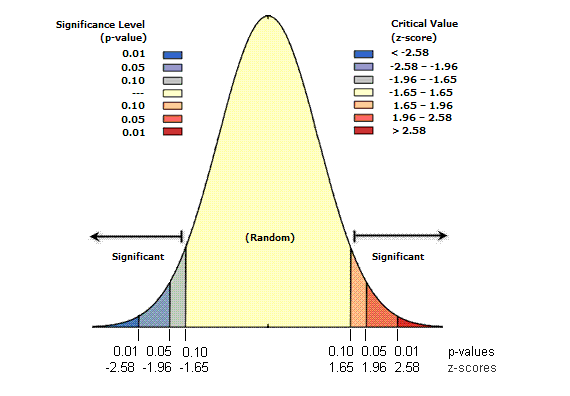  
Figure with explanations taken from [here](https://desktop.arcgis.com/de/arcmap/10.7/tools/spatial-statistics-toolbox/what-is-a-z-score-what-is-a-p-value.htm). 
Nice interactive page [here](https://www.geogebra.org/m/W9Nz53Ct).  
**Caveat**: The distribution here ist not the distribution of the (remainder of the) TS but a distribution of the augmented Dickey-Fuller test.

## 4. Decomposing a TS

A TS containing a trend and / or seasonality is obviously not stationary. How can we make it stationary?  
There are different options, e.g.
- detrending by linear regression; by differencing adjacent observations; by using `detrend()` of the `signal` library; ...
- deseasonalising by subtracting the average seasonal TS pattern; using `seasonal_decompse` of the `statsmodel` library; ...  


(After decomposition we make forecasts for all 3 components separately and add/multiply them afterwards again.)

#### Example

In [8]:
# https://www.kaggle.com/datasets/pkmisra/monthly-milk-production-pounds

milk = pd.read_csv('./data/milk_production.csv',
                   header=0, skipfooter=1, engine='python',
                   names=['month','production'], parse_dates=['month'])
milk.tail()

,month,production
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797
167,1975-12-01,843


**Short EDA**

Text(0.5, 1.0, 'Milk production')

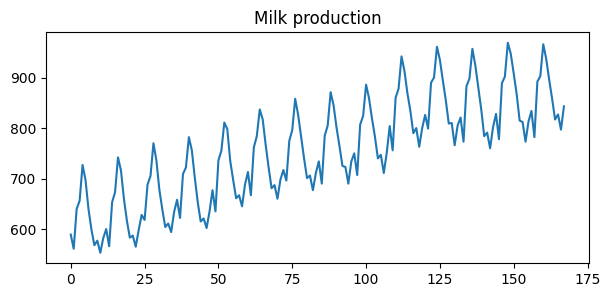

In [9]:
milk['production'].plot()
plt.title('Milk production')

**Train test split**

In [10]:
train = milk.copy().iloc[:-12]
test = milk.copy().iloc[-12:]

**define feature and target**

In [11]:
X_trend = np.array(train.index).reshape(-1, 1)
y_trend = train['production']

**buid trend model**

In [20]:
# trend model
trend_model = LinearRegression()

# even better: use quadratic polynome for the trend:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
trend_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

In [21]:
# fit model
trend_model.fit(X_trend,y_trend)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

**predict from model**

<Axes: >

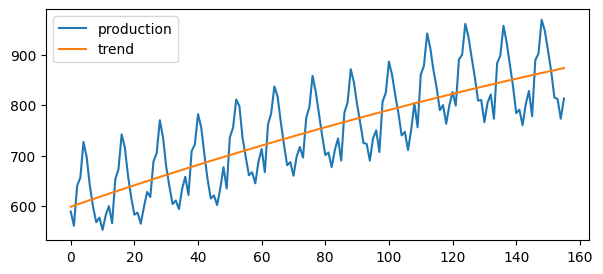

In [22]:
train['trend'] = trend_model.predict(X_trend)
train[['production','trend']].plot(legend=True)

**detrend TS**

<Axes: >

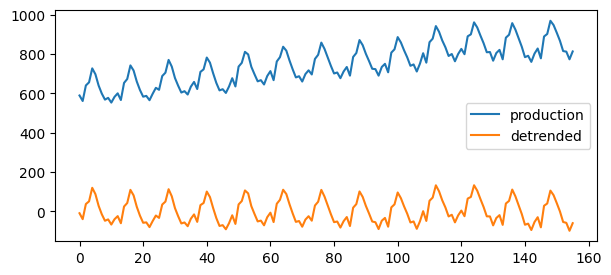

In [23]:
train['detrended'] = train['production'] - train['trend']
train[['production', 'detrended']].plot(legend=True)

**seasonality**

Text(0.5, 1.0, 'average seasonality')

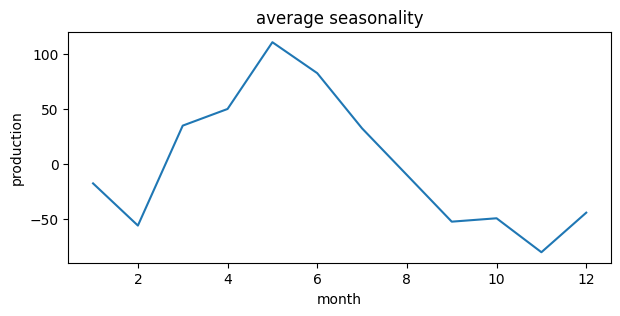

In [24]:
seasonality = train.groupby(train['month'].dt.month)['detrended'].mean()
seasonality.plot()
plt.ylabel('production')
plt.title('average seasonality')

**remainder**

In [25]:
train['remainder'] = train['detrended'] - pd.concat([seasonality] * 13, ignore_index=True)

<Axes: >

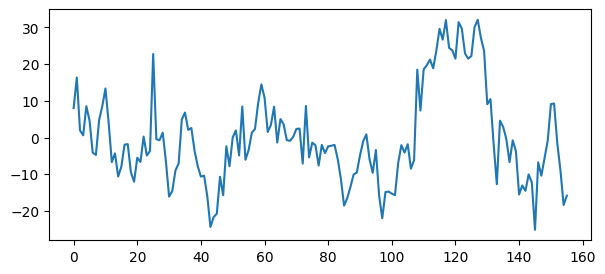

In [26]:
train['remainder'].plot()

**Is the remainder stationary?**

In [27]:
adf_stats, p, used_lag, n_obs, levels, information_criterion = adfuller(train['remainder'])

print(f"""   
            adf: {round(adf_stats,2)}
            p: {p} 
            used lag: {used_lag} 
            number of observations: {n_obs}
            {round(levels['1%'],2)} (p < 0.01; CI = 99%) 
            {round(levels['5%'],2)} (p < 0.05; CI = 95%)*
            {round(levels['10%'],2)} (p < 0.1 CI = 90%) 
            information criterion (AIC): {information_criterion}
            """)

   
            adf: -2.96
            p: 0.03856568924590735 
            used lag: 1 
            number of observations: 154
            -3.47 (p < 0.01; CI = 99%) 
            -2.88 (p < 0.05; CI = 95%)*
            -2.58 (p < 0.1 CI = 90%) 
            information criterion (AIC): 954.5012119505714
            


Because -2.96 is smaller than -2.88, we can reject the Nullhypothesis that the remainder is not stationary. Good!

## 5. Predicting the future with autoregression

It's easy to make forecastings for trend and seasonality. We concentrate only on the remainder now.   
The very **clever idea** is using autoregression. What is autoregression?  

In [28]:
autoreg = train[['remainder']].copy()
autoreg

,remainder
0,8.028350
1,16.345584
2,1.970510
3,0.595436
4,8.528055
...,...
151,9.254258
152,-1.524515
153,-8.995595
154,-18.389752


In [29]:
autoreg['lag1'] = autoreg['remainder'].shift(1)
autoreg.head()

,remainder,lag1
0,8.028350,NaN
1,16.345584,8.028350
2,1.970510,16.345584
3,0.595436,1.970510
4,8.528055,0.595436


Text(0, 0.5, 'remainder')

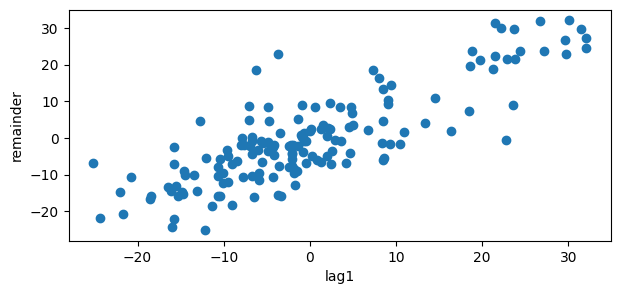

In [30]:
plt.scatter(autoreg['lag1'], autoreg['remainder'])
plt.xlabel('lag1')
plt.ylabel('remainder')

What does this scatterplot tell us?

GREAT! We can use the past to predict the presence. Or: we can predict $y_{t+1}$ from $y_t$  
Why? Because the remainder is not just random but somehow related in time,  
e.g., if it was very cold yesterday it will usually not be extremely warm today.

Let's test, how good a linear regression model can predict the remainder.

<Axes: >

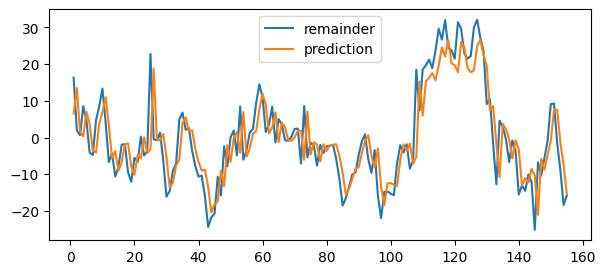

In [31]:
autoreg.dropna(inplace=True)  # due to shifting, there is one NaN value

ar_model = LinearRegression()
ar_model.fit(autoreg[['lag1']], autoreg['remainder'])
autoreg['prediction'] = ar_model.predict(autoreg[['lag1']])


autoreg[['remainder','prediction']].plot()

Not too bad, right?  


*Side note:* The prediction does not accept and is not based on time but on $y_{t-1}$ (even though the abscissa looks like it).  
&emsp; To forecast, we needed to input the last (present) $y$ to get the subsequent (future) one.  


To further improve the outcome, we could also try to use more than just one lag.  
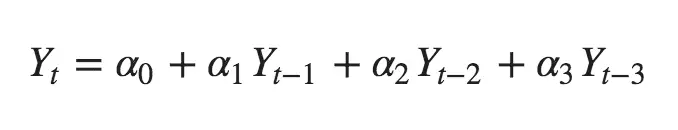  
In order to find out, how many lags make sense, the partial autocorrelation coefficient (PACF) is used.  
Let's consider 2 lags:  

## 6. Determination of Hyperparameters: Partial Autocorrelation Factor

In [32]:
autoreg['lag2'] = autoreg['remainder'].shift(2)
autoreg.dropna(inplace=True)

round(autoreg[['remainder', 'lag1', 'lag2']].corr(), 2)

,remainder,lag1,lag2
remainder,1.00,0.83,0.74
lag1,0.83,1.00,0.83
lag2,0.74,0.83,1.00


In [34]:
autoreg[['remainder', 'lag1', 'lag2']]

,remainder,lag1,lag2
3,0.595436,1.970510,16.345584
4,8.528055,0.595436,1.970510
5,4.614519,8.528055,0.595436
6,-4.145170,4.614519,8.528055
7,-4.751013,-4.145170,4.614519
...,...,...,...
151,9.254258,9.109953,-0.880505
152,-1.524515,9.254258,9.109953
153,-8.995595,-1.524515,9.254258
154,-18.389752,-8.995595,-1.524515


At first sight it seems sensible to add lag2 as well as there is some correlation between lag2 and remainder (0.74). However, we have already used lag1 to make some predictions on the remainder and should not look at lag2 versus remainder but on lag2 versus the unexplained "remainder of the remainder". Or in other words:  

**The relation between the remainder and lag2 might just be due to the relation between the remainder and lag1 and the relation between lag1 and lag2.**  

Corr(lag1, remainder) * Corr(lag1, lag2) = 0.83 * 0.83 = 0.69

Corr(lag2, remainder) = 0.77 is only slightly larger than 0.72 &rarr; lag2 has only low impact on predictions.  
The PACFs are basically the coefficients in a linear regression with h lags.  

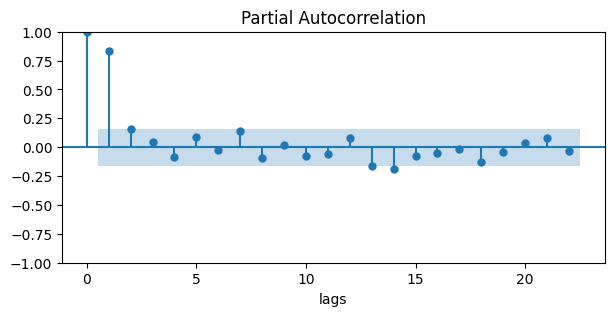

In [35]:
# Statsmodels provides a function called plot_pacf
# plot partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(autoreg['remainder'])
plt.xlabel('lags');

The **Box Jenkins Method** tells us to use 1 lag in this example for the number of lags of the AR model.  
That's a hyperparameter of the AR model, called **p**.

### Moving Averages Model (MA)

Moving average model is another way (other than AR) to model a time series.  
(MA can also be used to smoothen TS but that's not what we mean here.)    
Simple description how it works:  
1. Calculate the average value of the TS.
2. Calculate the error between that average and the first data point. This is the "error".
3. Use the average again for predicting the next time step but add a fraction of the "error" to that average.
4. Continue likewise until the present time point.
5. Now you can continue to predict the future in the same way.

Remarks:  
- The fraction needs to be optimized for a best fit.
- Instead of basing the next data point only on one single past data point, you can also use several (q)
- The optimal q can be determined by the autocorrelation coefficient (`from statsmodels.graphics.tsaplots import plot_acf`)
- This [video](https://www.youtube.com/watch?v=voryLhxiPzE) nicely explains MA model for TS.

The number of lags used for the MA model is denoted **q**. You want to use the ACF (!) plot to decide how many lags to use for a MA model. The ACF plot show the Pearson's correlation between different lags. 
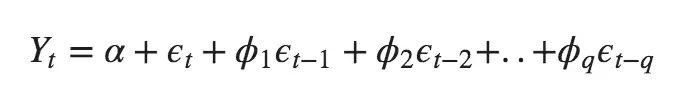  


### ARMA and other models

An **ARMA** model combines both, an **AR** model and a **MA** model. For both you need to define the number of lags to use, p and q, resp.  



\begin{array}{l|lll}
& \text{AR}(p) & \text{MA}(q) & \text{ARMA}(p,q) \\
\hline
\text{ACF} & \text{Tails off}^\text{1} & \text{Cuts off after
lag }q & \text{Tails off after lag (}q-p\text{)} \\
\text{PACF} & \text{Cuts off after lag }p &  \text{Tails
off}^\text{1}  & \text{Tails off after lag (}p-q\text{)}\\
\hline
\end{array}  

[Table source](https://www.geo.fu-berlin.de/en/v/soga-r/Advances-statistics/Time-series-analysis/Time-series-statistical-models/ARMA-models/index.html)  
[Video explanation](https://www.youtube.com/watch?v=-vSzKfqcTDg)  


There are further models like **ARIMA** which also include the "I" for *integrated*. You can use it for non-detrended TS because it detrends a TS by using the difference in values between adjacent time points. Again you need to define how many differences in turn should be used, d (stands for differencing). That means, for an ARIMA model you need the hyperparameters **p**,**d**, and **q** to form a model for prediction.

There are quite a lot of further models also taking into account seasonality (**SARIMA**) or exogenous factors (**ARMAX**).  

A **VAR** model means vector autoregression and is used if different TS influence each other. 

## 7. Automated solution

The above helps us to understand the concept of forecasting of TS. But there are also automated solutions. A very important one is implemented in the pmdarima library.  
Let's see how we can make use of it with the mild data set.

In [36]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm

model = pm.auto_arima(milk['production'], start_p=1, start_q=1,
                      test='adf',
                      max_p=3, max_q=3, m=12,
                      start_P=0, seasonal=True,
                      d=None, D=1, trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)


# print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1068.064, Time=1.32 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1119.969, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1081.584, Time=0.77 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1066.296, Time=1.59 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1114.995, Time=0.09 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1068.030, Time=2.02 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1067.976, Time=2.81 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1082.123, Time=0.66 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=8.01 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1072.280, Time=0.55 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=1067.796, Time=1.13 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1066.207, Time=0.91 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1114.845, Time=0.10 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1067.913, Time=1.58 sec
 ARIMA(1,1,0)(0,1,2)[12]

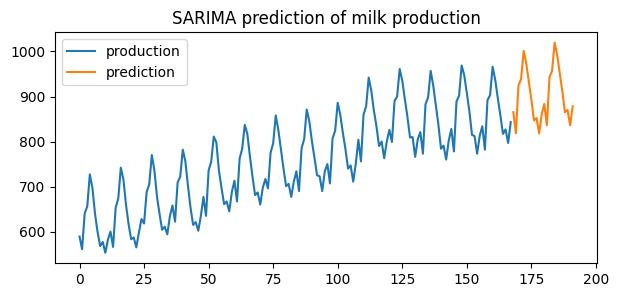

In [37]:
milk_prediction = model.predict(n_periods=24)  # use return_conf_int=True to draw a confidence interval

pd.concat([milk[['production']], milk_prediction]).plot()
plt.title('SARIMA prediction of milk production')
plt.legend(['production', 'prediction'])

## 8. Special considerations with TS

#### Imputation

It's usually not a good idea to fill gaps with the mean of the TS or with zero as that can spoil the continuity.  
But there are several other (partly simple) methods doing a good job:  
- Backward, Forward Fill
- Linear, Quadratic, Cubic Interpolation
- Mean of seasonal couterparts
- KNN Interpolation
- Predicting

#### Cross Validation

In TS the data's sequence is important. It's therefore not a good idea to use sklearn's `train_test_split()`.  
Instead better use `TimeSeriesSplit`.  

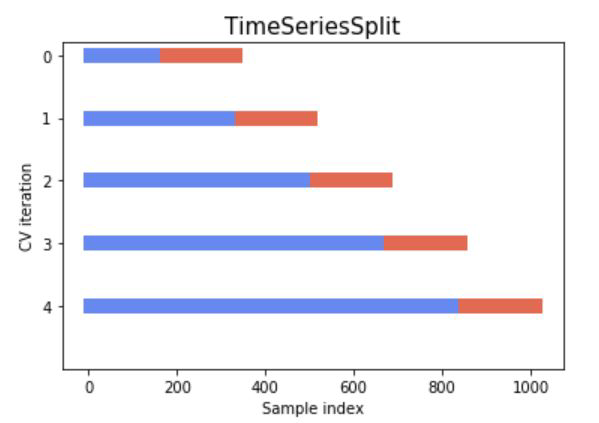  
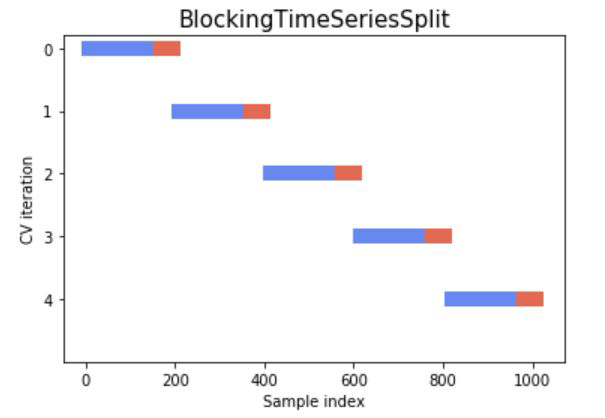
figure source and more reading [here](https://medium.com/@soumyachess1496/cross-validation-in-time-series-566ae4981ce4)

## 9. Outlook

This was a brief overview about the concept of TS.  
If you are interested in more details, you may want to have a look at the course material and find e.g. 
- some remarks about EDA
- about different methods of moving averages
- other automated solutions like facebook's prophet or CNN
- further reading material
- ...
